In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

colors = [
    '#D31F11'    ,  # red
    '#F47A00'    ,  # orange
    '#62C8D3'    ,  # light blue
    '#007191'    ,  # dark blue
    '#7A3E9D'    ,  # purple
    '#55A630'    ,  # green
    '#A3C72E'    ,  # lime
    '#595959'       # gray
]
plt.rcParams['font.family'] = 'monospace'

### Data: w/o ambient light

In [3]:
stage_0 = pd.read_csv('time_domain_data/without_ambient/stage_0.csv', delimiter=',', header = 1, names =['Time', 'ChA'])
stage_3 = pd.read_csv('time_domain_data/without_ambient/stage_3_04.csv', delimiter=',', header = 1, names =['Time', 'ChA', 'ChB'])
stage_4 = pd.read_csv('time_domain_data/without_ambient/stage_4_02.csv', delimiter=',', header = 1, names =['Time', 'ChA', 'ChB'])
stage_5 = pd.read_csv('time_domain_data/without_ambient/stage_5_02.csv', delimiter=',', header = 1, names =['Time', 'ChA', 'ChB'])

In [4]:
#Convert time from stage0 from ms to mikroseconds, and mV to V: 
time0 = stage_0['Time'] * 1e3
cha0 = stage_0['ChA'] #in mV
#And import the other stages:
time3 = stage_3['Time'] 
cha3 = stage_3['ChA']
chb3 = stage_3['ChB']

time4 = stage_4['Time']
cha4 = stage_4['ChA']
chb4 = stage_4['ChB']

time5 = stage_5['Time']
cha5 = stage_5['ChA']
chb5 = stage_5['ChB']

### Plot the data:

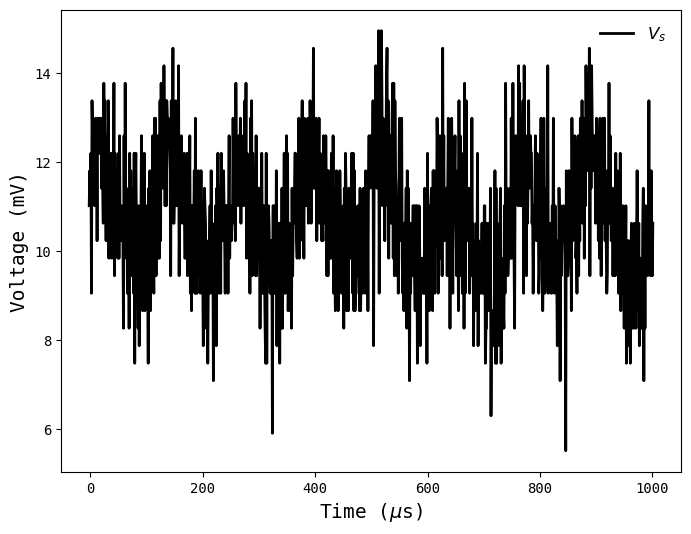

In [5]:
fig, ax = plt.subplots(figsize=(8,6))

ax.plot(time0, cha0, '-', linewidth =2, color='k', label = f'$V_s$')
ax.set_xlabel(f'Time ($\\mu$s)', fontsize=14)
ax.set_ylabel('Voltage (mV)', fontsize=14)

ax.legend(loc = 'best', fontsize = 12, frameon = False);

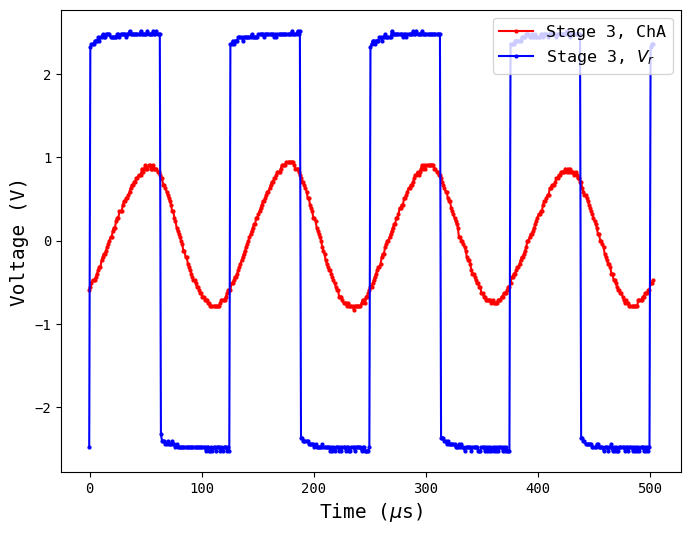

In [6]:
fig, ax = plt.subplots(figsize=(8,6))
ax.plot(time3, cha3, 'o-', ms = 2, color='r', label = 'Stage 3, ChA')
ax.plot(time3, chb3, 'o-', ms = 2, color='b', label = f'Stage 3, $V_r$')
ax.set_xlabel(f'Time ($\\mu$s)', fontsize=14)
ax.set_ylabel('Voltage (V)', fontsize=14)
ax.legend(loc = 'upper right', fontsize = 12);

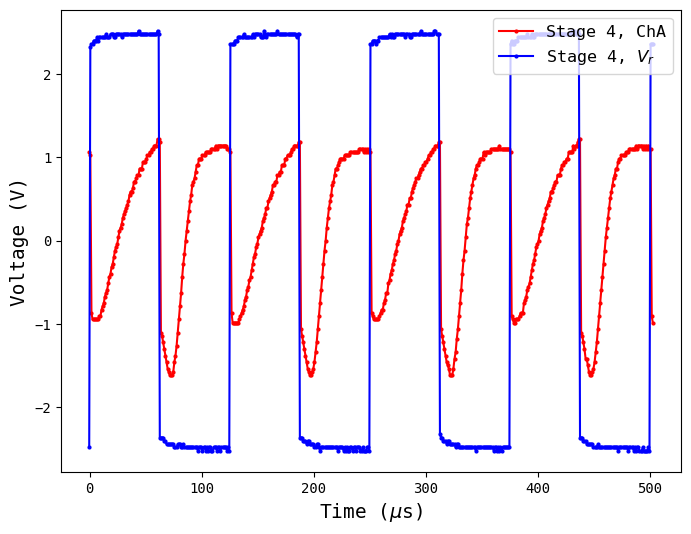

In [7]:
fig, ax = plt.subplots(figsize=(8,6))
ax.plot(time4, cha4, 'o-', ms = 2, color='r', label = 'Stage 4, ChA')
ax.plot(time4, chb4, 'o-', ms = 2, color='b', label = f'Stage 4, $V_r$')
ax.set_xlabel(f'Time ($\\mu$s)', fontsize=14)
ax.set_ylabel('Voltage (V)', fontsize=14)
ax.legend(loc = 'upper right', fontsize = 12);

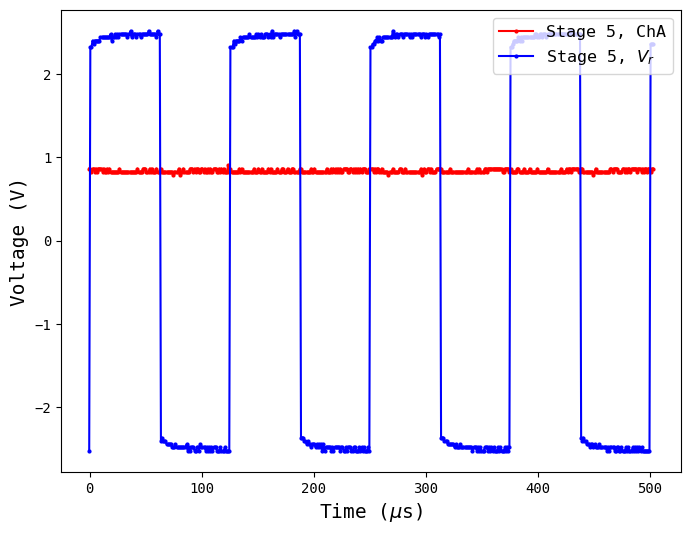

In [8]:
fig, ax = plt.subplots(figsize=(8,6))
ax.plot(time5, cha5, 'o-', ms = 2, color='r', label = 'Stage 5, ChA')
ax.plot(time5, chb5, 'o-', ms = 2, color='b', label = f'Stage 5, $V_r$')
ax.set_xlabel(f'Time ($\\mu$s)', fontsize=14)
ax.set_ylabel('Voltage (V)', fontsize=14)
ax.legend(loc = 'upper right', fontsize = 12);

### Plot the data together, such that we can see the effect of each stage. 

### Stage 0 + V_ref

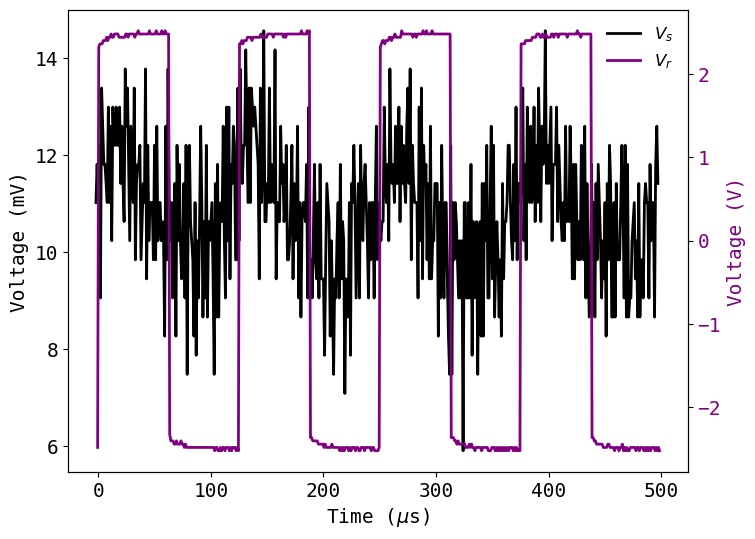

In [9]:
fig, ax = plt.subplots(figsize=(8,6))

line_ori = ax.plot(time0[:500], cha0[:500], '-', linewidth =2, color='k', label = f'$V_s$')
ax.set_xlabel(f'Time ($\\mu$s)', fontsize=14)
ax.set_ylabel('Voltage (mV)', fontsize=14, color = 'k')
ax.tick_params(axis='y', labelcolor='k')
ax.tick_params(axis='both', which='major', labelsize=14)

ax_twin = ax.twinx()
line_twin = ax_twin.plot(time3[:500], chb3[:500], '-', linewidth =2, color='purple', label = f'$V_r$')
ax_twin.set_ylabel('Voltage (V)', fontsize=14, color = 'purple')
ax_twin.tick_params(axis='y', labelcolor='purple')
ax_twin.tick_params(axis='both', which='major', labelsize=14)

lines = [line_ori[0], line_twin[0]]
labels = [line.get_label() for line in lines]
ax.legend(lines, labels, loc='best', fontsize =12, frameon=False);

### Stage 3->4

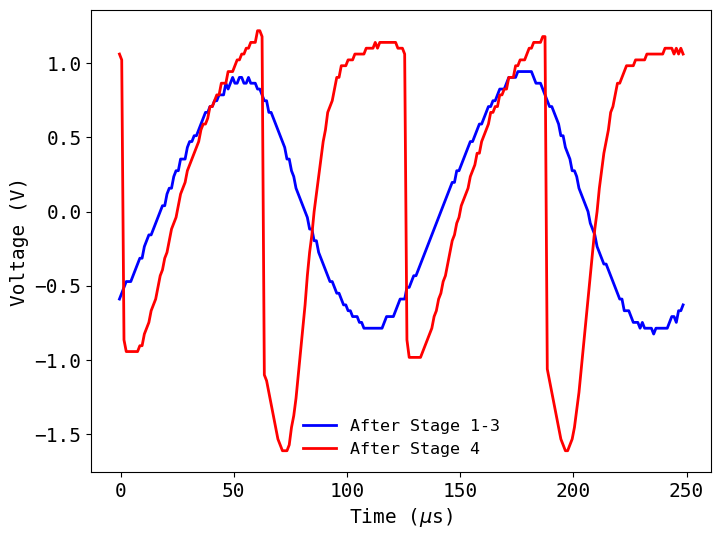

In [10]:
fig, ax = plt.subplots(figsize=(8,6))
ax.plot(time3[:250], cha3[:250], '-', linewidth =2, color='b', label = 'After Stage 1-3')
ax.plot(time4[:250], cha4[:250], '-', linewidth =2, color='r', label = 'After Stage 4')
#ax.plot(time3[:250], chb3[:250], '-', linewidth =2, color='k', alpha = 1, label = f'$V_r$')
ax.set_xlabel(f'Time ($\\mu$s)', fontsize=14)
ax.set_ylabel('Voltage (V)', fontsize=14)
ax.tick_params(axis='both', which='major', labelsize=14)
ax.legend(loc = 'best', fontsize = 12, frameon = False);

### Stage 4->5

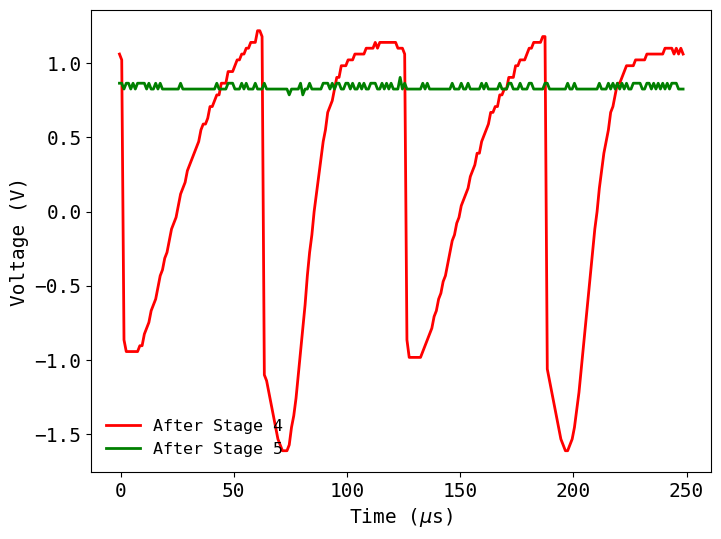

In [11]:
fig, ax = plt.subplots(figsize=(8,6))
ax.plot(time4[:250], cha4[:250], '-', linewidth =2, color='r', label = 'After Stage 4')
ax.plot(time5[:250], cha5[:250], '-', linewidth =2, color='g', label = 'After Stage 5')
#ax.plot(time4[:250], chb4[:250], '-', linewidth =2, color='k', alpha = 1, label = f'$V_r$')
ax.set_xlabel(f'Time ($\\mu$s)', fontsize=14)
ax.set_ylabel('Voltage (V)', fontsize=14)
ax.tick_params(axis='both', which='major', labelsize=14)
ax.legend(loc = 'lower left', fontsize = 12, frameon = False);

### Stage 1->5

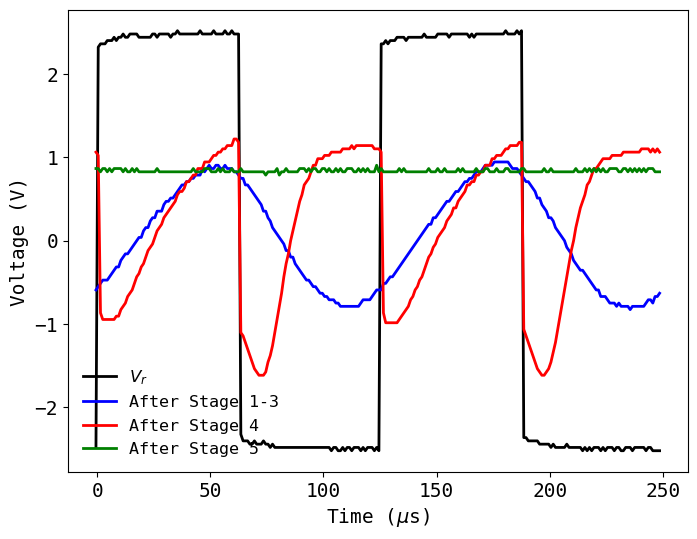

In [12]:
fig, ax = plt.subplots(figsize=(8,6))
ax.plot(time3[:250], chb3[:250], '-', linewidth =2, color='k', label = f'$V_r$')
ax.plot(time3[:250], cha3[:250], '-', linewidth =2, color='b', label = 'After Stage 1-3')
ax.plot(time4[:250], cha4[:250], '-', linewidth =2, color='r', label = 'After Stage 4')
ax.plot(time5[:250], cha5[:250], '-', linewidth =2, color='g', label = 'After Stage 5')
#ax.plot(time4[:250], chb4[:250], '-', linewidth =2, color='k', alpha = 1, label = f'$V_r$')
ax.set_xlabel(f'Time ($\\mu$s)', fontsize=14)
ax.set_ylabel('Voltage (V)', fontsize=14)
ax.tick_params(axis='both', which='major', labelsize=14)
ax.legend(loc = 'lower left', fontsize = 12, frameon = False);

### Double plot

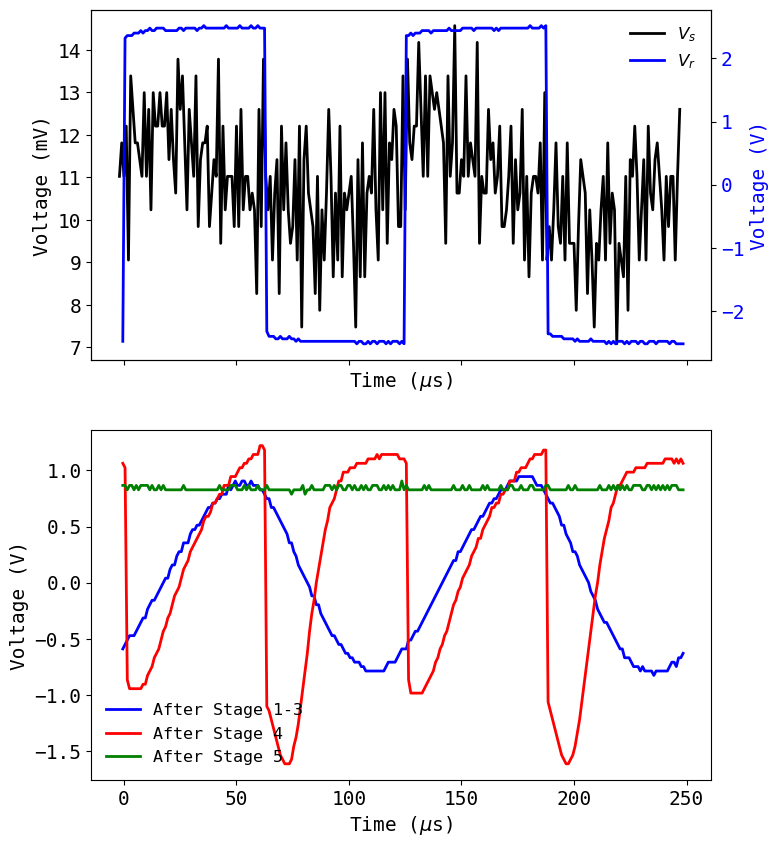

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(8,10), sharex=True)

line_ori = axes[0].plot(time0[:250], cha0[:250], '-', linewidth =2, color='k', label = f'$V_s$')
axes[0].set_xlabel(f'Time ($\\mu$s)', fontsize=14)
axes[0].set_ylabel('Voltage (mV)', fontsize=14, color = 'k')
axes[0].tick_params(axis='y', labelcolor='k')
axes[0].tick_params(axis='both', which='major', labelsize=14)

ax_twin = axes[0].twinx()
line_twin = ax_twin.plot(time3[:250], chb3[:250], '-', linewidth =2, color='b', label = f'$V_r$')
ax_twin.set_ylabel('Voltage (V)', fontsize=14, color = 'b')
ax_twin.tick_params(axis='y', labelcolor='b')
ax_twin.tick_params(axis='both', which='major', labelsize=14)

lines = [line_ori[0], line_twin[0]]
labels = [line.get_label() for line in lines]
axes[0].legend(lines, labels, loc='best', fontsize =12, frameon=False);

axes[1].plot(time3[:250], cha3[:250], '-', linewidth =2, color='b', label = 'After Stage 1-3')
axes[1].plot(time4[:250], cha4[:250], '-', linewidth =2, color='r', label = 'After Stage 4')
axes[1].plot(time5[:250], cha5[:250], '-', linewidth =2, color='g', label = 'After Stage 5')
axes[1].set_xlabel(f'Time ($\\mu$s)', fontsize=14)  
axes[1].set_ylabel('Voltage (V)', fontsize=14)
axes[1].tick_params(axis='both', which='major', labelsize=14)
axes[1].legend(loc = 'lower left', fontsize = 12, frameon = False);


### Final plots

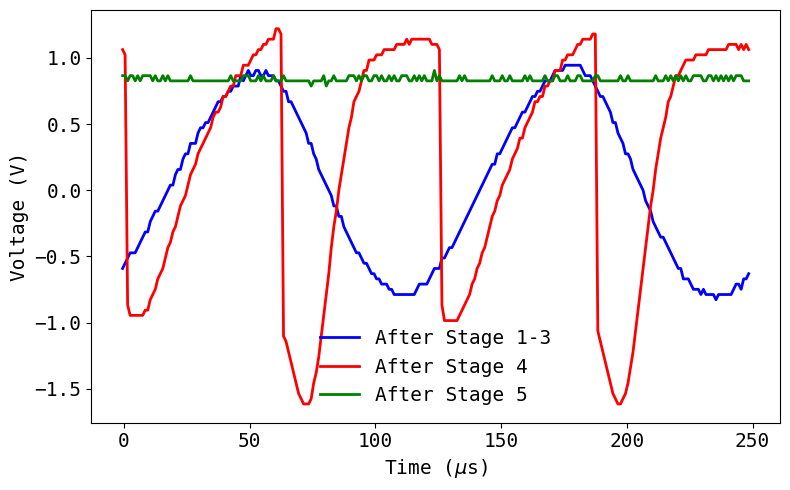

In [14]:
fig, ax = plt.subplots(figsize=(8,5))
ax.plot(time3[:250], cha3[:250], '-', linewidth =2, color='b', label = 'After Stage 1-3')
ax.plot(time4[:250], cha4[:250], '-', linewidth =2, color='r', label = 'After Stage 4')
ax.plot(time5[:250], cha5[:250], '-', linewidth =2, color='g', label = 'After Stage 5')
ax.set_xlabel(f'Time ($\\mu$s)', fontsize=14)
ax.set_ylabel('Voltage (V)', fontsize=14)
ax.tick_params(axis='both', which='major', labelsize=14)
ax.legend(loc = 'best', fontsize = 14, frameon = False)
plt.tight_layout()
plt.savefig('stages_1to5.pdf', dpi=600, bbox_inches='tight', pad_inches=0.02);

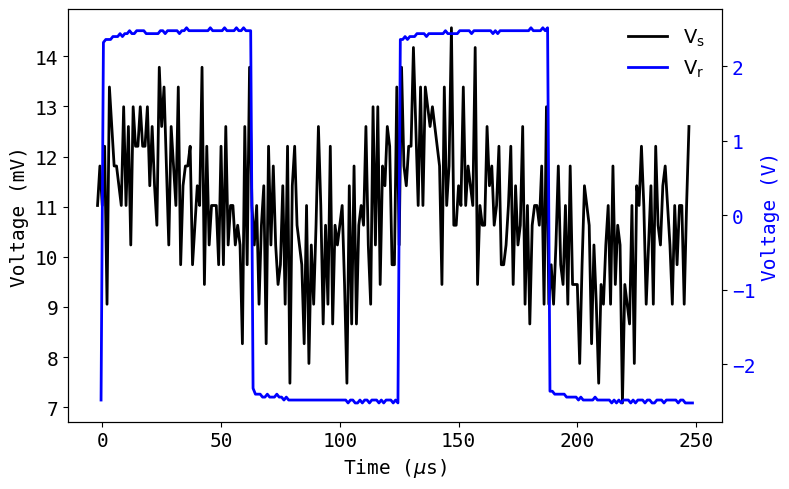

In [15]:
fig, ax = plt.subplots(figsize=(8,5))
line_ori = ax.plot(time0[:250], cha0[:250], '-', linewidth =2, color='k', label = r'$\mathrm{V_s}$')
ax.set_xlabel(f'Time ($\\mu$s)', fontsize=14)
ax.set_ylabel('Voltage (mV)', fontsize=14, color = 'k')
ax.tick_params(axis='y', labelcolor='k')
ax.tick_params(axis='both', which='major', labelsize=14)

ax_twin = ax.twinx()
line_twin = ax_twin.plot(time3[:250], chb3[:250], '-', linewidth =2, color='b', label = r'$\mathrm{V_r}$')
ax_twin.set_ylabel('Voltage (V)', fontsize=14, color = 'b')
ax_twin.tick_params(axis='y', labelcolor='b')
ax_twin.tick_params(axis='both', which='major', labelsize=14)

lines = [line_ori[0], line_twin[0]]
labels = [line.get_label() for line in lines]
ax.legend(lines, labels, loc='best', fontsize =14, frameon=False)
plt.tight_layout()
plt.savefig('stage0plusref.pdf', dpi=600, bbox_inches='tight', pad_inches=0.02);
